In [ ]:
# !pip install tensorflow[and-cuda]

##### **Generate Regression Data: (Continuous Data)**

In [2]:
from sklearn.datasets import make_regression

# generate a random regression problem
X, y = make_regression(n_samples=1000, n_features=150, n_informative=10 ,noise=0.1, random_state=1)


##### **Preprocessing:**

In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [7]:
# Split the dataset:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.34, random_state=1)

processor = MinMaxScaler()

processor.fit(x_train)
x_train = processor.transform(x_train)
x_test = processor.transform(x_test)

##### **Building the model (AutoEncoder):: Encoder & Decoder**

##### **Encoder:**

In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, ReLU, BatchNormalization, Dropout

inputs = x_train.shape[1]

#define the encoder
encoder_input = Input(shape=(inputs,))
encoder_layer = Dense(inputs*2)(encoder_input)
encoder_layer = BatchNormalization()(encoder_layer)
encoder_layer = ReLU()(encoder_layer)

# define the end of the encoder:: the bottleNeck layer:
inputs_bottleNeck = inputs
bottleNeck_layer = Dense(inputs_bottleNeck)(encoder_layer)

##### **Decoder:**

In [20]:
# Define the decoder
decoder = Dense(inputs*2)(bottleNeck_layer)
decoder = BatchNormalization()(decoder)
decoder = ReLU()(decoder)
decoder_output = Dense(inputs, activation='linear')(decoder)

# define the autoencoder model
autoencoder = Model(inputs= encoder_input, outputs=decoder_output)

##### **Complining & Configuration:**

In [21]:
autoencoder.compile(optimizer='adam', loss='mse')

#### **Plot The Autoencoder:**

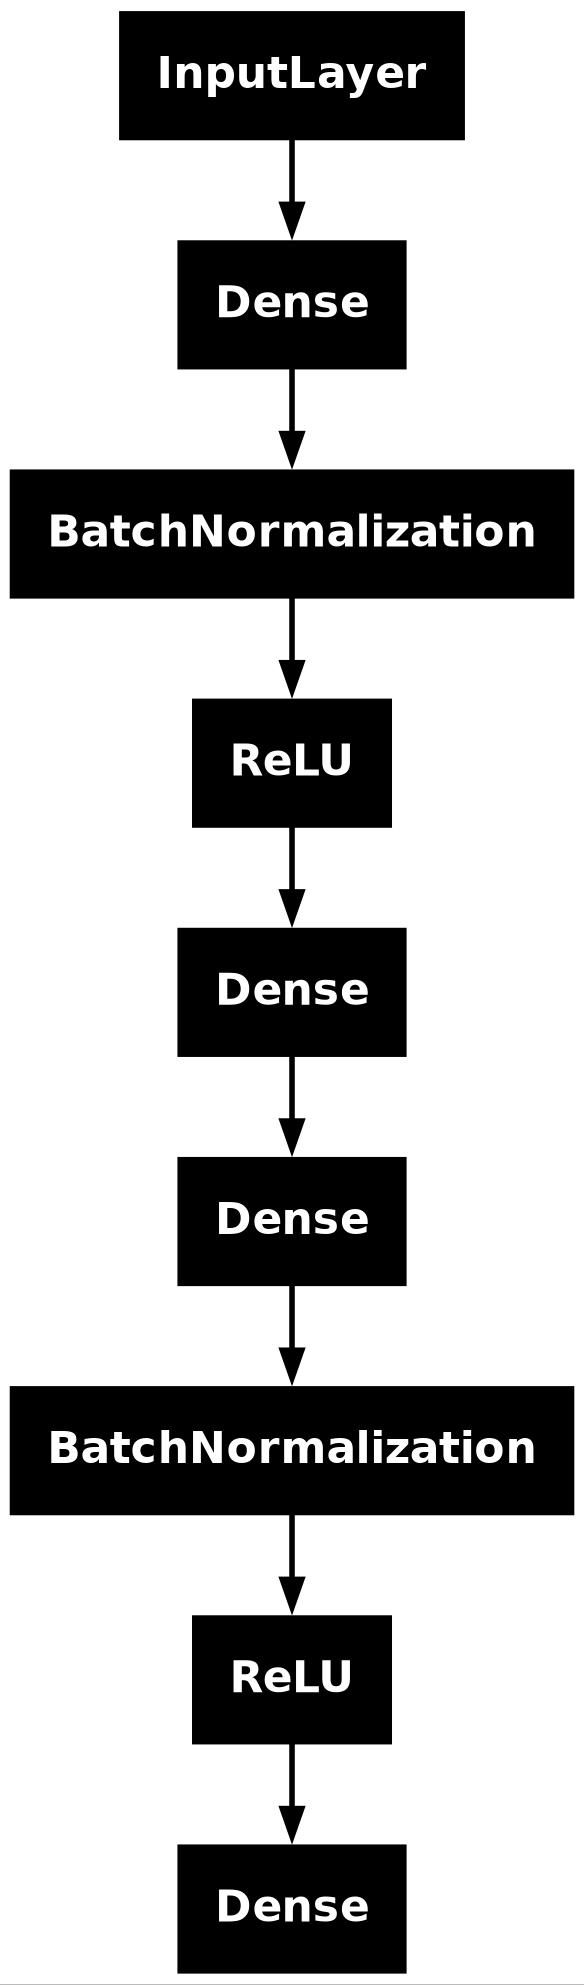

In [26]:


from tensorflow.keras.utils import plot_model
plot_model(autoencoder,'autoencoder.jpg')